# Tutorial 3: Decoding the Surface Code

In Notebook 1, we decoded Shor’s code by looking up a correction for each syndrome. In Notebook 2, we built rotated surface-code patches and used lattice surgery to perform logical operations. When we added noise, we saw detector events and uncorrected logical failures, but we did not use the detector events to correct the results.

We now use that measurement record to decode a noisy logical CNOT. Its checks are measured over several rounds, and the check pattern changes as patches merge and split. Faults can affect the data, the measurement reports, or both. The decoder uses the resulting pattern of detector events to predict whether the tracked logical readout needs to be flipped.

We first build the CNOT with TQEC and inspect the detector events generated by noise. We then use Stim to construct a detector error model and build a simple lookup decoder that tries one or two mechanisms. After seeing what this decoder can explain and where it falls short, we introduce PyMatching and compare the logical failure rates on the same shots. Finally, we use Sinter to automate the simulation and decoding.

## 1. Build a logical CNOT with TQEC

In Notebook 2, we described a lattice-surgery CNOT as three logical measurements: $Z_CZ_A$, then $X_AX_D$, then $Z_A$. Here $C$ is the control, $D$ the target, and $A$ an ancillary logical patch. TQEC provides a construction of this CNOT, so we do not need to place every patch and specify every check by hand.

TQEC represents the operation as a **BlockGraph**. Its cubes describe regions of a protected logical computation, and its pipes connect those regions across space or time. The geometric $z$ direction represents time.

We use `cnot(Basis.Z)`, which fills the CNOT’s input and output ports with Z-basis preparation and readout. This sets up the Z-basis experiment whose logical correlations we will test.

In [1]:
from pathlib import Path
import webbrowser
from tqec import Basis
from tqec.gallery import cnot

# Build the CNOT block graph
cnot_graph = cnot(Basis.Z)

# Save and open its interactive 3D viewer
viewer_path = Path("cnot_view.html").resolve()
cnot_graph.view_as_html(write_html_filepath=viewer_path)
vis = webbrowser.open(viewer_path.as_uri())

### Reading the CNOT BlockGraph

Read the graph **from bottom to top**: height represents time. The tall column on the left follows the control patch $C$ from input to output. The tall column on the right follows the target patch $D$. The shorter column in the middle is the ancillary patch $A$, which participates in the two joint measurements.

Each block stands for a region of the protected computation, not a single qubit or gate. Compiling the graph at a chosen code distance produces the physical circuit, including repeated check measurements. 
With the default distance-three settings used below, TQEC expands this CNOT BlockGraph into four successive time blocks of **three check-measurement rounds each** (we can also specify the number of rounds when compiling the circuit). The detector time coordinates therefore run from 0 through 11. These are round labels, not individual physical gate steps:

- **Times 0–2:** prepare the control and target patches and begin measuring their checks.
- **Times 3–5:** introduce the ancilla and perform the first joint measurement, $\bar Z_C\bar Z_A$.
- **Times 6–8:** perform the second joint measurement, $\bar X_A\bar X_D$, then read out the ancillary region.
- **Times 9–11:** continue checking the separated output patches before final readout.

The **lower connection** joins $C$ to $A$ first, for the logical $ZZ$ measurement. Farther up in time, the **upper connection** joins $A$ to $D$ for the logical $XX$ measurement. The ancilla is then read out. The measurement outcomes determine a known CNOT byproduct, which we can track in the Pauli frame.

Red faces are $X$-type boundaries, and blue faces are $Z$-type boundaries. The face colors identify boundary types. The joint logical measurement depends on how the patches are joined. In this first connection, TQEC joins the control and ancilla at $X$-type boundary faces.

<img src="assets/blockgraph_cnot.png" alt="CNOT BlockGraph" width="320">

### Choose a logical observable

The BlockGraph shows the shape of the CNOT. We also need to choose which logical relationship to test. A **correlation surface** traces a relation between logical operators at the inputs and outputs through the computation.

For this graph and the installed TQEC version, the two returned surfaces describe:

1. `correlation_surfaces[0]`: $\bar Z_C^{\mathrm{in}} \rightarrow \bar Z_C^{\mathrm{out}}$.
2. `correlation_surfaces[1]`: $\bar Z_D^{\mathrm{in}} \rightarrow \bar Z_C^{\mathrm{out}}\bar Z_D^{\mathrm{out}}$.

These are the propagation rules $U\bar Z_CU^\dagger=\bar Z_C$ and $U\bar Z_DU^\dagger=\bar Z_C\bar Z_D$ for a CNOT. The second surface branches through the interaction, so we choose it for this experiment. TQEC compiles its measurement relation into the tracked Stim observable `L0`.

Later, an **observable flip** means that this relation differs from its noiseless reference. It is not simply the statement that a measured qubit returned 1. We track one logical correlation here, so the reported failure rate applies to `L0`, rather than every possible logical error of the CNOT.

In [2]:
# Find the logical observables supported by this CNOT graph.
correlation_surfaces = cnot_graph.find_correlation_surfaces()
print(f"Number of correlation surfaces: {len(correlation_surfaces)}")

# Choose the surface that passes through the interaction between the patches.
chosen_surface = correlation_surfaces[1]  # This is the branching surface shown in figure (b).

# Save a viewer with that surface highlighted.
surface_viewer_path = Path("cnot_correlation_surface.html").resolve()
cnot_graph.view_as_html(
    write_html_filepath=surface_viewer_path,
    pop_faces_at_directions=("-Y",),  # Open one side so the surface is visible.
    show_correlation_surface=chosen_surface,
)
vis = webbrowser.open(surface_viewer_path.as_uri())

Number of correlation surfaces: 2


### Reading the correlation surface
<table>
  <tr>
    <td align="center">
      <img src="assets/correlation_surface0.png" alt="Control Z correlation surface" width="263">
    </td>
    <td align="center">
      <img src="assets/correlation_surface1.png" alt="Branching Z correlation surface" width="280">
    </td>
  </tr>
  <tr>
    <td align="center"><b>(a)</b> Control Z</td>
    <td align="center"><b>(b)</b> Target Z through the CNOT</td>
  </tr>
</table>


The deep blue overlay is the selected logical $Z$ correlation surface.
 In **(a)**, the surface [0] connects $\bar Z_C^{\mathrm{in}}$ to $\bar Z_C^{\mathrm{out}}$. In **(b)**, [1] connects $\bar Z_D^{\mathrm{in}}$ to both $\bar Z_C^{\mathrm{out}}$ and $\bar Z_D^{\mathrm{out}}$.

### Compile the CNOT into a circuit

TQEC uses a size-scaling parameter $k$. For this construction, the spatial code distance is

$$
d=2k+1.
$$

We choose $k=1$, giving distance three. By default, each time block also contains $2k+1=3$ check rounds, giving 12 rounds for this CNOT. The duration can be changed separately using `block_temporal_height` in `compile_block_graph()`.

We add circuit-level noise with parameter $p=0.001$. `NoiseModel.uniform_depolarizing(p)` includes depolarizing noise after gates and during idle periods, faults after preparation, and measurement-report flips. Its two-qubit gate noise includes correlated two-qubit Pauli faults, so this extends the single-qubit noise example from Notebook 2.

TQEC generates the physical gates together with detector definitions and the chosen logical observable. Stim will use this annotated circuit for sampling and error-model analysis.

In [3]:
from tqec import NoiseModel, compile_block_graph

k = 1                         # d = 2k + 1 = 3
physical_error_rate = 0.001

# Turn the logical BlockGraph into a distance-three physical circuit.
compiled_cnot = compile_block_graph(
    cnot_graph,
    observables=[chosen_surface],
)
noisy_cnot_circuit = compiled_cnot.generate_stim_circuit(
    k=k,
    noise_model=NoiseModel.uniform_depolarizing(physical_error_rate),
    do_not_use_database=True,  # Avoid writing TQEC's detector cache to disk.
)

print(f"Physical qubits: {noisy_cnot_circuit.num_qubits}")
print(f"Logical observables: {noisy_cnot_circuit.num_observables}")
print(f"Detectors: {noisy_cnot_circuit.num_detectors}")


Physical qubits: 81
Logical observables: 1
Detectors: 256


### Count the detectors

A **detector** is a parity check on a specified set of measurement reports
whose combined parity is predictable when there are no faults.
A **detection event** occurs when the reported parity differs from that
expected value.

For an unchanged stabilizer measured in consecutive rounds, the reports
should agree. Its detector bit is therefore

$$
d_i(t)=s_i(t)\oplus s_i(t-1),
$$

where $s_i(t)$ is the reported bit for stabilizer $i$ in round $t$.
Here, $d_i(t)=1$ means a detection event occurred. Preparation, surgery
transitions, and final readout can require relations involving different
sets of measurement reports.

Our circuit contains **256 detector definitions**, distributed across
12 time coordinates. Each shot evaluates all 256 relations. 

A separate distance-three patch has
$$
d^2 - 1 = 8
$$
stabilizer checks: 4 $X$ checks and 4 $Z$ checks, 2 weight-4 and 2 boundary weight-2 each.
Initially and finally, the circuit has two separate patches, giving 
$$
8+8=16
$$
check reports per round.

During the first surgery stage, the merged region contains
$$
9(C) + 3(\mathrm{bridge}) + 9(A)=21
$$
data qubits. 

After measuring the joint parity, the region encodes one remaining logical degree of freedom with $21-1=20$ independent stabilizer checks. In this circuit, these are $8 X$ checks and $12 Z$ checks.
Meanwhile, $D$ remains separate and continues its eight checks:
$$
\underbrace{20}_{C\text{ merged with }A}
+
\underbrace{8}_{D}
=
\boxed{28\text{ reports per round}}.
$$
During the second surgery stage, $A$ and $D$ form a 21-data-qubit region with 20 checks (12 X and 8 Z), while $C$ resumes its eight checks. Therefore,
$$
3(16)+3(28)+3(28)+3(16)=\boxed{264}
$$
stabilizer-check reports.

Usually, a check report gives a detector by comparison with the previous report. But newly introduced checks can have unknown initial signs.
In this circuit:
- Round 0: eight first X-check reports are not predictable from the Z-basis preparation.
- Round 3: eight newly introduced Z-check reports (4 seam + 4 on A) do not yet supply deterministic detector relations.
- Round 6: four newly introduced X-check reports on the new $A,D$ seam do not yet supply deterministic detector relations.
The first reports still establish values for later comparisons. They simply cannot be treated as known initial signs. For this schedule, we subtract
$$
8+8+4=20.
$$

Moreover, we need extra detectors to check whether the final data readouts agree with the last Z-check reports.
For a distance-three patch, one logical Z representative uses three data qubits. We nevertheless measure all nine data qubits in Z. The logical-string parity gives the logical outcome, while other subsets reconstruct stabilizer parities. From those nine readouts, we also calculate the parities of its four Z stabilizers. Each is compared with its last check report:
$$
d_j=s_j^{\mathrm{last}}
\oplus
\bigoplus_{i\in\mathrm{support}(S_j)}z_i,
\qquad j=1,2,3,4,
$$
where $z$ is the data readout, $s$ is the last reported stabilizer measurement before reading out the data, $d$ is the detector bit. That gives four additional detectors, one per Z-check history.

- **Round 8:** reading out the ancillary region closes four Z-check histories.
- **Round 11:** reading out $C$ and $D$ closes four Z-check histories per patch.

At the surgery boundary, the exact relation can also include bridge readouts. These relations are generated from the circuit, rather than assuming that every detector compares just two consecutive reports.

Together, the data readouts supply $4+8=12$ additional detectors without requiring extra stabilizer measurements.

Finally, we derive the number of detectors by counting check reports, removing the ones that cannot yet define a detector, then adding readout relations:
$$
\boxed{256=264-20+12}.
$$


This count belongs to the default $d=3$, 12-round schedule. Changing the distance or duration changes the detector count. The compiled circuit, rather than this arithmetic alone, defines the exact relations.

### Sample and plot the first shot

A **shot** is one execution of the entire noisy 12-round circuit. We generate 2,000 independent shots, then plot shot 0. Rerunning the next cell generates fresh samples, so the events and rates will change.

Only detectors that fired are plotted in orange, with their detector IDs. The coordinates locate the detector relations in spacetime, not the qubits where faults are known to have occurred. The printed `L0` flip is the simulator’s uncorrected result relative to the noiseless reference. Even when detectors fire, `L0` need not flip. Shot 0 may also have no events.

Shot 0: 3 detection events
Fired detectors: ['D172', 'D191', 'D196']
Logical observable L0 flipped before decoding: False
Uncorrected L0 flip rate: 25.6%


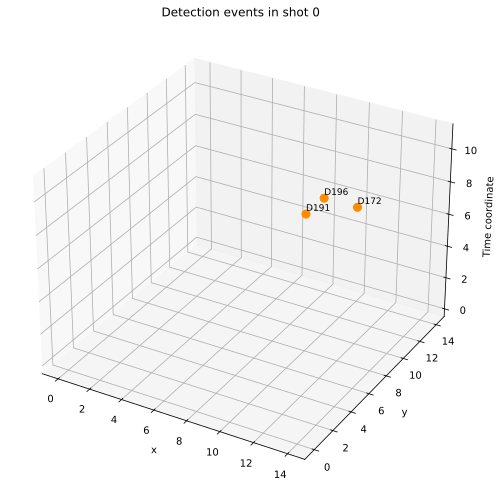

In [4]:
import numpy as np
import matplotlib.pyplot as plt

n_shots = 2_000

# Generate fresh samples each time this cell runs.
detector_events, observable_flips = (
    noisy_cnot_circuit.compile_detector_sampler().sample(
        shots=n_shots,
        separate_observables=True,
    )
)

# Inspect the first shot.
shot_id = 0
fired_ids = np.flatnonzero(detector_events[shot_id])
coordinates = noisy_cnot_circuit.get_detector_coordinates()

print(f"Shot {shot_id}: {len(fired_ids)} detection events")
print("Fired detectors:", [f"D{i}" for i in fired_ids])
print(
    "Logical observable L0 flipped before decoding:",
    bool(observable_flips[shot_id, 0]),
)
print(f"Uncorrected L0 flip rate: {observable_flips[:, 0].mean():.1%}")

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

# Plot only the detectors that fired, without depth-dependent fading.
if len(fired_ids):
    fired_positions = np.array([
        coordinates[int(i)][:3] for i in fired_ids
    ])

    ax.scatter(
        *fired_positions.T,
        color="darkorange",
        s=65,
        depthshade=False,
    )

    # Label each event with its detector ID.
    for detector_id, (x, y, t) in zip(fired_ids, fired_positions):
        ax.text(x, y, t + 0.2, f"D{detector_id}", fontsize=9)
else:
    ax.text2D(
        0.5, 0.5, "No detection events",
        transform=ax.transAxes,
        ha="center",
    )

# Preserve the full circuit's coordinate range without plotting gray dots.
all_positions = np.array([
    coordinates[i][:3]
    for i in range(noisy_cnot_circuit.num_detectors)
])
ax.set_xlim(all_positions[:, 0].min() - 1, all_positions[:, 0].max() + 1)
ax.set_ylim(all_positions[:, 1].min() - 1, all_positions[:, 1].max() + 1)
ax.set_zlim(all_positions[:, 2].min() - 0.5, all_positions[:, 2].max() + 0.5)

ax.set(xlabel="x", ylabel="y", zlabel="Time coordinate")
ax.set_title(f"Detection events in shot {shot_id}")
plt.tight_layout()
plt.show()

### Follow the detection events in one shot
Each row below identifies a detector that fired. The detector ID connects
this event to entries in the DEM and nodes in the matching graph.

The coordinates locate the detector relation in space and time. They do
not identify the physical qubit that suffered an error. An event means
that the parity of the measurements defining that detector differed from
its expected value.

In [5]:
# Reuse the selected shot without sampling again.
fired_ids = np.flatnonzero(detector_events[shot_id])
coordinates = noisy_cnot_circuit.get_detector_coordinates()

print(f"Shot {shot_id}: {len(fired_ids)} detection events\n")
print(f"{'Detector':<12}{'x':>8}{'y':>8}{'time':>8}")
print("-" * 36)

for detector_id in fired_ids:
    coords = coordinates.get(int(detector_id), [])

    # Our TQEC circuit uses the first three coordinates as x, y, time.
    # Show a dash if a coordinate is unavailable.
    values = [
        f"{coords[i]:g}" if i < len(coords) else "—"
        for i in range(3)
    ]
    print(
        f"{'D' + str(detector_id):<12}"
        f"{values[0]:>8}{values[1]:>8}{values[2]:>8}"
    )

Shot 0: 3 detection events

Detector           x       y    time
------------------------------------
D172              12      10       8
D191              10       8       8
D196              10      10       8


## 2. Decode the noisy CNOT

We have seen how noise produces detector events and can flip the logical
readout. We now use those events to predict whether the readout needs
to be corrected.

The detector events alone do not tell us which faults occurred. To
interpret them, we first ask Stim to generate a **detector error model
(DEM)** from our noisy circuit. This model describes possible fault
effects, their probabilities, and whether they flip the tracked logical
observable.

We first use the DEM to build a simple lookup decoder that searches for explanations containing at most one or two mechanisms.

We then use **PyMatching** to build a decoder from this model. Given the
events from one shot, the decoder finds a likely explanation and predicts
whether the logical bit should be flipped. In this notebook, we apply
that correction to the readout in software.

### Build the detector error model

The orange points are detector events observed in one shot. To explain them, the decoder needs a model of what faults could produce them.

Stim generates a **detector error model (DEM)** by analysing the gates, noise instructions, detector definitions, and logical observable in the circuit. This is a calculation of possible fault effects, so generating the model does not sample another shot.

For example, `error(0.001) D4 D7 L0` describes a mechanism with probability $0.001$ that flips detectors `D4` and `D7` and observable `L0`. If it occurred alone, those two detectors would fire. 

Since there are 256 detectors, there are at most 
$$
\boxed{2^{256}\approx1.16\times10^{77}}
$$
binary patterns. Circuit constraints can make some patterns unreachable, and their probabilities vary greatly.

Different physical faults can contribute to the same DEM entry when they have the same detector and logical effects. An entry therefore describes an effective mechanism, rather than necessarily one particular faulty gate.

The DEM does not list all these patterns. Its entries describe individual effective mechanisms. Their effects combine by XOR to produce the observed pattern.
For example:
$$
\underbrace{\{D0,D1\}}_{\text{mechanism A}}
\oplus
\underbrace{\{D1,D2\}}_{\text{mechanism B}}
=
\underbrace{\{D0,D2\}}_{\text{observed events}}.
$$
So the model stays relatively compact by storing mechanisms and probabilities, while the decoder searches for combinations that explain a shot.

The decoder therefore looks for a likely combination of mechanisms that reproduces the observed detector events. Entries without an `L0` label matter too, because they can explain events without requiring a logical flip.

In [6]:
# Analyze the noisy CNOT circuit without sampling another shot.
detector_error_model = noisy_cnot_circuit.detector_error_model()

# Display a few possible error mechanisms.
# These are model entries, not faults identified in our plotted shot.
error_entries = [
    instruction
    for instruction in detector_error_model.flattened()
    if instruction.type == "error"
]

print(f"Detectors in the model: {detector_error_model.num_detectors}")
print(f"Logical observables in the model: {detector_error_model.num_observables}")
print(f"Error mechanisms in the model: {len(error_entries)}")
print("\nExample mechanisms:")
for entry in error_entries[:4]:
    print(entry)

Detectors in the model: 256
Logical observables in the model: 1
Error mechanisms in the model: 3466

Example mechanisms:
error(0.0012662) D0
error(0.00259527) D0 D6 L0
error(0.00451643) D0 D19
error(0.00292699) D1


### Count error sites

The compiled circuit uses 81 physical qubits and performs 12 check-measurement
rounds. Each round has seven scheduled moments:

$$
1\text{ preparation layer}
+5\text{ interaction layers}
+1\text{ measurement layer}
=\boxed{7\text{ moments per round}}.
$$

A moment is a scheduled layer of operations that can run in parallel.
TQEC uses five interaction slots to accommodate different check schedules:

| Check schedule | Slot 1 | Slot 2 | Slot 3 | Slot 4 | Slot 5 |
|---|---|---|---|---|---|
| Horizontal hook orientation | Gate | Gate | Gate | Wait | Gate |
| Vertical hook orientation | Gate | Wait | Gate | Gate | Gate |

Each weight-four check still uses four ancilla–data gates. The shared
five-slot schedule accommodates both interaction orders without gate
conflicts. This is a feature of the TQEC convention used here, rather
than a universal requirement for surface codes.

Across the whole circuit, we have

$$
81\times12\times7=6804
$$

qubit–moment slots.

Under `uniform_depolarizing(0.001)`, each slot contributes one noise
location, except that a two-qubit gate occupies two slots but receives
one joint noise channel. We therefore subtract one location for each
two-qubit gate.

To count these gates, a separate distance-three patch has four weight-two
and four weight-four checks, requiring

$$
4(2)+4(4)=24
$$

ancilla–data gates per round. A merged region has eight weight-two and
twelve weight-four checks, requiring

$$
8(2)+12(4)=64
$$

gates per round.

There are six rounds with two separate patches and six rounds with a
merged region plus a separate patch. Therefore,

$$
N_{\mathrm{2q}}=6(24+24)+6(64+24)=816.
$$

The total number of error sites is

$$
\boxed{N_{\mathrm{sites}}=6804-816=5988.}
$$

This counts locations where a noise channel acts. The number of possible
fault outcomes is larger because a depolarizing channel can apply
different Pauli errors. The parameter $0.001$ sets their probabilities,
not the number of locations.

The 5,988 noise locations and 3,466 DEM entries count different things. A location may allow several Pauli faults, different faults may have identical detector and logical effects, and faults with no tracked effect do not need an error entry. The DEM then represents combinations through XOR rather than listing every possible shot pattern.

### A lookup decoder with one or two mechanisms

We now build a simple decoder that tries to explain each shot using
at most one or two DEM mechanisms:

1. Look for a single mechanism whose detector pattern exactly matches the observed events.
2. If `max_combinations = 2`, also try pairs. Their effects combine by XOR, so a detector flipped by both cancels.
3. Choose the most probable matching explanation.
4. Combine its `L0` labels by XOR to decide whether to flip the logical readout.
5. If nothing matches, leave the readout unchanged and mark the shot as unmatched.

For an explanation $S$, the selected mechanisms occur and all the others do not. Under the independent-mechanism model,

$$
P(S)=\prod_{j\in S}p_j\prod_{k\notin S}(1-p_k).
$$

Every explanation shares the factor $P(\varnothing)=\prod_k(1-p_k)$. We can therefore compare them using

$$
R(S)=\frac{P(S)}{P(\varnothing)}
=\prod_{j\in S}\frac{p_j}{1-p_j}.
$$

We choose the highest-scoring explanation among those containing at most one or two mechanisms. An empty detector pattern also allows the explanation with zero mechanisms, whose score is 1.

Note that when `max_combinations = 2`, we don't need to look through every pair of mechanisms, instead, suppose the observed detection event is $D$, the first chosen mechanism is $A$, we know for sure the other mechanism has to be $D\oplus A$ to be a match.

In [7]:
from collections import defaultdict

# Build the mechanism list and index it by detector pattern.
mechanisms = []
by_pattern = defaultdict(list)

# Turn DEM into a list of mechanisms with their scores.
for entry in detector_error_model.flattened():
    # Skip DEM metadata, such as detector-coordinate declarations.
    if entry.type != "error":
        continue
    # Read mechanism probability.
    p = entry.args_copy()[0]
    # Read detector targets and logical observable targets.
    targets = entry.targets_copy()
    pattern = frozenset(t.val for t in targets if t.is_relative_detector_id())
    flip = any(t.is_logical_observable_id() and t.val == 0 for t in targets)
    by_pattern[pattern].append(len(mechanisms))
    mechanisms.append((pattern, flip, p / (1 - p)))

print(mechanisms[:5])

[(frozenset({0}), False, 0.0012678096461738587), (frozenset({0, 6}), True, 0.002602027466171882), (frozenset({0, 19}), False, 0.004536924041340904), (frozenset({1}), False, 0.00293558065923295), (frozenset({1, 3}), False, 0.0015346181108437903)]


In [8]:
def decode(mechanisms, observed, max_combinations=1):

    # Choosing zero mechanisms explains an empty pattern with score 1.
    best_score = 1.0 if not observed else -1.0
    best_flip = False

    # Try single mechanisms.
    for i in by_pattern.get(observed, ()):
        _, flip, score = mechanisms[i]
        if score > best_score:
            best_score, best_flip = score, flip

    # Try pairs, using XOR to look up the required second pattern.
    if max_combinations == 2:
        for i, (pattern, flip, odds) in enumerate(mechanisms):
            needed = observed ^ pattern

            for j in by_pattern.get(needed, ()):
                if j <= i:  # Two distinct mechanisms, each pair tried once.
                    continue

                _, other_flip, other_odds = mechanisms[j]
                score = odds * other_odds

                if score > best_score:
                    best_score = score
                    best_flip = flip ^ other_flip

    return best_flip, best_score >= 0

In [9]:
shot_patterns = [
    frozenset(np.flatnonzero(events)) for events in detector_events
]
actual_flips = observable_flips[:, 0]
n_sampled = len(shot_patterns)

print(f"{'Method':<24} {'Unmatched shots':>18} {'Failure rate':>15}")
print("-" * 59)
print(f"{'No decoding':<24} {'—':>18} {actual_flips.mean():>14.2%}")

lookup_results = {}

for max_combinations in (1, 2):
    # Calculate each distinct pattern's answer only once.
    cache = {
        pattern: decode(mechanisms, pattern, max_combinations)
        for pattern in set(shot_patterns)
    }

    predictions = np.array([cache[p][0] for p in shot_patterns])
    unmatched = np.array([not cache[p][1] for p in shot_patterns])

    # Simulator truth is used only here, to evaluate the predictions.
    failure_rate = np.mean(predictions != actual_flips)

    # Keep the results for later analysis.
    lookup_results[max_combinations] = {
        "predictions": predictions,
        "unmatched": unmatched,
        "failure_rate": failure_rate,
    }

    label = f"Up to {max_combinations} mechanism(s)"
    unmatched_count = f"{unmatched.sum()}/{n_sampled}"
    print(f"{label:<24} {unmatched_count:>18} {failure_rate:>14.2%}")

Method                      Unmatched shots    Failure rate
-----------------------------------------------------------
No decoding                               —         25.60%
Up to 1 mechanism(s)              1572/2000         23.55%


Up to 2 mechanism(s)              1060/2000         18.25%


Allowing two mechanisms can explain more shots than allowing only one. Compare the unmatched counts and failure rates above to see the effect on this sample batch. An unmatched shot has no explanation within the chosen limit, so our decoder leaves its readout unchanged.

Extending the search to more mechanisms would cover more patterns, but would also increase the search cost. We next use PyMatching to find an explanation without imposing this one-or-two-mechanism limit.

### Build the PyMatching decoder

**PyMatching** implements minimum-weight perfect matching. It represents detectors as graph nodes. A graphlike mechanism connects two detectors, or one detector to a boundary when its other endpoint produces no detector event.

An edge with mechanism probability $p_e$ receives weight

$$
w_e=\ln\frac{1-p_e}{p_e}.
$$

For small $p_e$, this is approximately $-\ln p_e$. Less likely mechanisms receive larger weights. Here $p_e$ is the edge’s probability after the model has been constructed, which can differ from the circuit’s physical noise parameter $p$.

A circuit fault can affect more than two detectors. We request `decompose_errors=True` so that Stim attempts to express these effects as graphlike components. For example, `error(p) D0 D1 ^ D2 D3` groups two components of one mechanism. Ordinary matching treats the components as separate edges and does not fully use their correlation.

For a shot, the decoder selects a minimum-total-weight set of edges whose effects reproduce the detector events. A fired detector has an odd number of selected incident edges. At an intermediate detector that did not fire, an even number cancels. The decoder makes this choice for the whole pattern, rather than selecting a nearest neighbor for each event independently.

Each selected edge also carries logical-flip labels. XORing those labels predicts whether `L0` flipped. We print the selected connections below. A row is one edge, and several rows can form a longer path. These are inferred graph effects, not unique physical faults identified by the decoder.

The simulator’s `observable_flips` are kept separate and used only to evaluate the prediction. Agreement means decoding succeeded for `L0`. The correction is a change to the interpreted readout, so this example does not apply physical recovery gates or construct a complete Pauli frame for a continuing computation.

In [10]:
import pymatching

# Ask Stim for a graph-like form of the circuit's error model.
dem = noisy_cnot_circuit.detector_error_model(
    decompose_errors=True
)
# Build the matching graph and its weights from the model.
decoder = pymatching.Matching.from_detector_error_model(dem)

syndrome = detector_events[shot_id]
selected_edges = decoder.decode_to_edges_array(syndrome)

# Accumulate logical effects from the selected graph mechanisms.
predicted_flips = np.zeros(
    noisy_cnot_circuit.num_observables, dtype=np.uint8
)
total_weight = 0.0

print(
    f"{'Selected connection':<30}"
    f"{'Weight':>9}  {'Logical flips'}"
)
print("-" * 60)

for u, v in selected_edges:
    u, v = int(u), int(v)

    if v == -1:
        edge = decoder.get_boundary_edge_data(u)
        connection = f"D{u} → boundary"
    else:
        edge = decoder.get_edge_data(u, v)
        connection = f"D{u} → D{v}"

    # With a DEM-built decoder, fault_ids identify logical observables.
    logical_ids = sorted(edge["fault_ids"])
    labels = ", ".join(f"  L{i}" for i in logical_ids) or "  none"

    for logical_id in logical_ids:
        predicted_flips[logical_id] ^= 1

    total_weight += edge["weight"]
    print(f"{connection:<30}{edge['weight']:>9.3f}  {labels}")

# Simulator truth is used only for evaluation, not by the decoder.
predicted = bool(predicted_flips[0])
actual = bool(observable_flips[shot_id, 0])
remaining_error = predicted != actual

print(f"\nTotal selected weight: {total_weight:.3f}")
print(f"Decoder predicts L0 flipped:       {predicted}")
print(f"Simulator recorded L0 flipped:     {actual}")
print(f"Decoder prediction matches:        {predicted == actual}")
print(f"Logical error remains after correction: {remaining_error}")

Selected connection              Weight  Logical flips
------------------------------------------------------------
D172 → D191                       6.283    none
D196 → boundary                   4.528    none

Total selected weight: 10.811
Decoder predicts L0 flipped:       False
Simulator recorded L0 flipped:     False
Decoder prediction matches:        True
Logical error remains after correction: False


### Measure the logical failure rate

We now decode every shot in the same sample batch. Before decoding, a failure is a flip of the tracked observable `L0`. After decoding, a failure remains when the decoder’s predicted flip disagrees with the simulator’s flip. This evaluates the same observable on the same shots before and after correction.

The table compares no decoding, both lookup limits, and PyMatching on exactly the same shots. Lookup failure rates include unmatched shots. PyMatching uses the decomposed graph model described above, while the lookup uses whole entries from the original DEM.

In [11]:
# Decode the same shots used by the lookup decoder.
batch_predicted_flips = decoder.decode_batch(detector_events)

# Simulator truth is used only to evaluate predictions.
actual_flips = observable_flips[:, 0]
n_sampled = len(actual_flips)
raw_failure_rate = actual_flips.mean()
matching_failures = batch_predicted_flips[:, 0] != actual_flips
matching_failure_count = np.count_nonzero(matching_failures)
decoded_failure_rate = matching_failure_count / n_sampled

print(f"{'Method':<24} {'Failures / shots':>20} {'Failure rate':>15}")
print("-" * 61)
results = [("No decoding", actual_flips)]
for limit in (1, 2):
    failures = lookup_results[limit]["predictions"] != actual_flips
    results.append((f"Up to {limit} mechanism(s)", failures))
results.append(("PyMatching", matching_failures))

for name, failures in results:
    count = np.count_nonzero(failures)
    print(f"{name:<24} {f'{count} / {n_sampled}':>20} {count / n_sampled:>14.2%}")

Method                       Failures / shots    Failure rate
-------------------------------------------------------------
No decoding                        512 / 2000         25.60%
Up to 1 mechanism(s)               471 / 2000         23.55%
Up to 2 mechanism(s)               365 / 2000         18.25%
PyMatching                          39 / 2000          1.95%


## 3. Automate the experiment with Sinter

We have sampled the circuit, called PyMatching, and counted failures explicitly. TQEC’s documented simulation workflow uses **Sinter** to organize these steps across experiments.

Here we call Sinter directly with the same circuit and DEM. This preserves the chosen observable, distance, noise, and number of rounds. We select `pymatching` as its decoder, so both workflows use the same decoding algorithm.

Sinter generates fresh shots. The two failure-rate estimates should be statistically consistent, but they need not match exactly, especially with only 2,000 samples. We are comparing an explicit workflow with an automated one. For larger studies, TQEC’s `start_simulation_using_sinter()` also generates circuits across lists of code sizes and noise rates.

In [12]:
import sinter

stats = sinter.collect(
    num_workers=1,
    tasks=[
        sinter.Task(
            circuit=noisy_cnot_circuit,
            detector_error_model=dem,
            json_metadata={"experiment": "logical CNOT"},
        )
    ],
    decoders=["pymatching"],
    max_shots=n_sampled,  # Use the same sample count.
    print_progress=False,
)

result = stats[0]
sinter_shots = result.shots - result.discards
sinter_rate = result.errors / sinter_shots

print(f"{'Workflow':<25} {'Failures / shots':>20} {'Failure rate':>15}")
print("-" * 62)
print(
    f"{'Direct PyMatching':<25}"
    f"{f'{matching_failure_count} / {n_sampled}':>20}"
    f"{decoded_failure_rate:>14.2%}"
)
print(
    f"{'Sinter + PyMatching':<25}"
    f"{f'{result.errors} / {sinter_shots}':>20}"
    f"{sinter_rate:>14.2%}"
)

Workflow                      Failures / shots    Failure rate
--------------------------------------------------------------
Direct PyMatching                   39 / 2000         1.95%
Sinter + PyMatching                 48 / 2000         2.40%


## Summary

We followed a noisy logical CNOT from its TQEC BlockGraph to a decoded logical result:

1. TQEC generated the physical circuit, detector relations, and one tracked logical observable.
2. Stim sampled the noisy circuit and calculated a DEM describing possible fault effects.
3. A lookup decoder searched for one- or two-mechanism explanations. Its unmatched shots showed the limit of that search.
4. PyMatching used detector events and graph weights to predict logical flips without that fixed mechanism limit.
5. We compared those predictions with simulation truth, then automated the experiment with Sinter.

The measured improvement comes from interpreting the measurement history. We did not need to identify every physical fault or apply a correction gate before the final readout. The remaining failure rate measures mistakes in the decoder’s prediction for `L0`.

A natural next experiment is to repeat the comparison over physical error rates and code distances. The 2,000-shot example is an introduction to the workflow; rarer logical failures require more samples to estimate reliably.

### References

- [TQEC: CNOT compilation and simulation workflow](https://tqec.github.io/tqec/user_guide/quick_start.html)
- [Stim: detector error model format](https://github.com/quantumlib/Stim/blob/main/doc/file_format_dem_detector_error_model.md)
- [PyMatching: decoding Stim circuits](https://pymatching.readthedocs.io/en/stable/)